<p style="text-align: center">
<img src="../../../assets/images/dtlogo.png" alt="Duckietown" width="50%">
</p>

# 🚙 💻 04 - Wheel encoder based odometry

"Odometry" is the problem of "measuring the path", or evolution of the pose in time, of the robot. 

We can solve the odometry problem by using the measurements from wheel encoders, and a so called "dead-reckoning" model, to estimate the evolution of the pose in time through an iterative procedure, such that:

<p style="text-align:center;"><img src="../../../assets/images/odometry/odometry-1.png" width="500" alt="odometry-1"></p>   

$$ x_{k+1} = x_k + \Delta x_k $$
$$ y_{k+1} = y_k + \Delta y_k $$
$$ \theta_{k+1} = \theta_k + \Delta \theta_k $$

Where initial conditions ($x_0$, $y_0$, $\theta_0$) are assumed to be known. The increments can be calculated by:

1. **Determining the rotation of each wheel through the wheel encoder mesurements**

$$\Delta \phi_k = N_k \cdot \alpha$$

where $N_k$ is the number of pulses, or "ticks", measured from the encoders in the $k-th$ time interval, $\alpha = \frac{2 \pi}{N_{tot}}$ is the rotation per tick, and $N_{tot}$ the total number of ticks per revolution ($N_{tot} = 135$ for the wheel encoders we will be using). This relation is evaluated for each wheel, yielding $\Delta \phi_{l,k}$ and $\Delta \phi_{r,k}$ for the left and right wheels respectively.

2. **Deriving the total distance travelled by each wheel**

<p style="text-align:center;"><img src="../../../assets/images/odometry/odometry-d.png" width="250" alt="odometry-d"></p> 

Assuming the wheel radii are the same (equal to $R$) for both wheels, the distance travelled by each wheel is given by:

$$ d_{l/r, k} = R \cdot \Delta \phi_{l/r,k}$$

3. **Finding the rotation and distance travelled by the robot (frame)**

<p style="text-align:center;"><img src="../../../assets/images/odometry/odometry-2.png" width="250" alt="odometry-2"></p>    

Under the assumption of no slipping of the robot wheels, we can derive the distance travelled by the origin of the robot frame (point $A$) and the rotation of the robot $\Delta \theta$:

$$ d_{A, k} = \frac{d_{r,k} + d_{l,k}}{2} $$
$$ \Delta \theta_{k} = \frac{d_{r,k} - d_{l,k}}{2L}$$

4. **Expressing the robot motion in the world reference frame**

<p style="text-align:center;"><img src="../../../assets/images/odometry/odometry-3.png" width="250" alt="odometry-3"></p>

Finally, we can express the estimated motion in the world reference frame and find:

$$ \Delta x_k = d_{A, k} \cos\theta_k $$
$$ \Delta y_k = d_{A, k} \sin\theta_k $$

# 🚙 💻 Let's get started!

In this activity you will write a function that produces an estimate of the pose of the Duckiebot, given mesurements from the wheel encoders and an initial position:

In [1]:
# Run and do not edit this magic cell. 
# It helps getting things to work throughout the Jupyter notebook - in particular importing changes in functions made in files other than this workspace.

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

x0 = y0 = 0.0 # meters
theta0 = np.deg2rad(0) # radians

print(x0,y0, theta0)

0.0 0.0 0.0


## 1. Determining the rotation of each wheel through the wheel encoder mesurements

We have seen how to read wheel encoder data in the [wheel encoder tutorial](../../notebooks/03-Wheel-Encoders-Tutorial/wheel_encoders_tutorial.ipynb). We can now use this data to measure the rotation of each wheel. 

### Wheel encoder calibration factor

Remember that there are 135 ticks per revolution on the wheel encoders we are using. 

In [3]:
# Write the correct expressions 
import numpy as np 

N_tot = 135 # total number of ticks per revolution
alpha = 2 * np.pi / N_tot # wheel rotation per tick in radians

print(f"The angular resolution of our encoders is: {np.rad2deg(alpha)} degrees")

The angular resolution of our encoders is: 2.6666666666666665 degrees


Assume that at the current update the left and right motor encoders have produced the following measurements:

In [6]:
# Feel free to play with the numbers to get an idea of the expected outcome

ticks_left = 1
prev_tick_left = 0

ticks_right = 0
prev_tick_right = 0

How much did each wheel rotate? 

In [13]:
# How much would the wheels rotate with the above tick measurements? 

# Repetita iuvant: don't confuse degrees and radians when expressing angles
# Machines always use radians, humans make sense of degrees better. 
# Mixing these up is a very very common source of error!

delta_ticks_left = ticks_left - prev_tick_left # delta ticks of left wheel
delta_ticks_right = ticks_right - prev_tick_right # delta ticks of right wheel
rotation_wheel_left = alpha * delta_ticks_left # total rotation of left wheel
rotation_wheel_right = alpha * delta_ticks_right # total rotation of right wheel

print(f"The left wheel rotated: {np.rad2deg(rotation_wheel_left)} degrees")
print(f"The right wheel rotated: {np.rad2deg(rotation_wheel_right)} degrees")

The left wheel rotated: 2.6666666666666665 degrees
The right wheel rotated: 0.0 degrees


## 2. 🚙 💻 Evaluate distance travelled by each wheel

Now let's calculate the distance travelled by each wheel. It depends on the wheel radii. We need to determine them! We could use advanced odometry calibration procedures, but let's take it a step at the time. 

If you have a robot, take a ruler and measure your wheel radii (let's assume they are the same):

In [8]:
# What is the radius of your wheels (assuming they are identical)? 

R = 0.0318 # insert value measured by ruler (meters)

Note: the default value used in simulation and on the robot is $R = 0.0318 \text{m}$.

In [9]:
# What is the distance travelled by each wheel?

d_left = R * alpha
d_right = R * alpha

print(f"The left wheel travelled: {d_left} meters")
print(f"The right wheel rotated: {d_right} meters")

The left wheel travelled: 0.0014800392056911916 meters
The right wheel rotated: 0.0014800392056911916 meters


### 🚙 Save your new value of `R`

If you have a Duckiebot, let's make sure it remembers its new wheel radius! 

directly edit the `config/modcon_config.yaml` file in the repository and set the `radius` field to your measured value.

You can keep going — let's save the baseline measurement too!

## 3. 🚙 💻 Find the rotation and distance travelled by the Duckiebot

If you have previoulsy set your robot's gain so that the wheels do not slip, the travelled distance of point $A$ (origin of the robot frame) will be given by the average of the distances travelled by the wheels:

In [15]:
# How much has the robot travelled? 

d_A = (d_left + d_right)/2  # robot distance travelled in robot frame (meters)

print(f"The robot has travelled: {d_A} meters")

The robot has travelled: 0.0014800392056911916 meters


To calculate the rotation of the robot we need to measure the baseline too - or the distance between the center of the two wheels: 

<p style="text-align:center;"><img src="../../../assets/images/odometry/odometry-baseline.png" width="300" alt="odometry-baseline"></p>  

If you have a robot, take a ruler and measure it! 

In [11]:
# What is the baseline length of your robot? 

baseline_wheel2wheel = 0.1 #  Take a ruler and measure the distance between the center of the two wheels (meters) 

Note: the default value, and that used in simulation, is $baseline = 0.1m$.

We are now ready to calculate the rotation of the Duckiebot:

In [14]:
# Of what angle has the robot rotated? 

Delta_Theta =  (d_right - d_left) / 2 * baseline_wheel2wheel   # [radians]

print(f"The robot has rotated: {np.rad2deg(Delta_Theta)} degrees")

The robot has rotated: 0.0 degrees


### 🚙 Save your new value of `baseline`

Let's make sure your Duckiebot remembers its wheel baseline!

directly edit the `config/modcon_config.yaml` file in the repository and set the `baseline` field to your measured value.

# 💻 🚙 Write the odometry function

We have been practicing so far. 

Now it is time to write the functions that will actually be running on the robot (in simulation or on the physical one). 

You will write two functions:

1. A function that calculates the rotation of a wheel given a message from the wheel encoders and the previous number of ticks measured;

2. The actual odometry function, that will receive as inputs the kinematic model parameters, the pose estimate at the previous iteration, and the rotation of each wheel. The initial position is assumed to be $q_0 = [0,0,0]^T$.

## Calculating the rotation of each wheel

Implement the function `delta_phi` inside the file [odometry_activity.py](../../packages/odometry_activity.py).

This function should output the wheel rotation (in radians) since last measurements, receiving as input the current and previous update wheel encoder readings.

## Estimating the odometry

Implement the function `pose_estimation` inside the file [odometry_activity.py](../../packages/odometry_activity.py).
This function computes the `(x, y, theta)` estimate by aggregating computed wheel rotations and the (known) geometry of the robot.

### Test the `pose_estimation()` function

Unit tests are useful to check if a piece of code does its intended job. Although the interaction of different functions might yield surprises even when each function produces the expected outcome, it is good pratice to test them in isolation before prime time! These are called "unit tests", and:

> If it ain't tested, it's broken.
>
> --Roboticists, level 9

Let's see if the function you wrote above passes the following test!

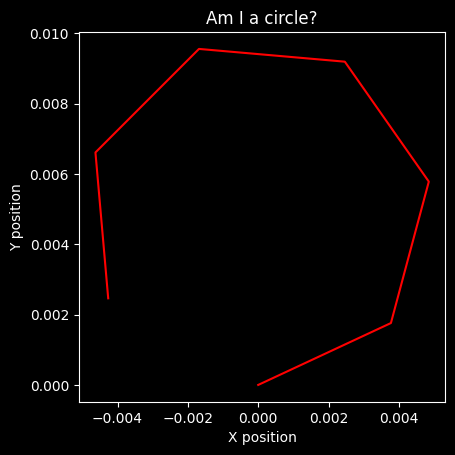

In [18]:
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath(''), '../../packages'))

from tests.unit_test import UnitTestOdometry
from odometry_activity import pose_estimation

# UnitTestOdometry tests the `pose_estimation` function defined in odometry_activity.py.
# The test is successful if you get a circle in the plot. 
# Anything different from a circle indicates that the odometry function has something wrong.

UnitTestOdometry(R, baseline_wheel2wheel, pose_estimation)

A successful test will yield something similar to this: 

<p style="text-align:center;"><img src="../../../assets/images/odometry/UnitTestValidation-2022.png" width="800" alt="successful-test-odometry"></p>  


# 💻 🚙 Run the Activity

Let's now see how the odometry is working in pratice. 

💻 🚙 The first objective of this activity is to run the scripts you just wrote on a simulated and real robot, and see how they perform. 

💡 The second objective is reflecting on the outcome and trying to have the theory agree with your observations. 

## 💻 Running the odometry in simulation

Now let's see how your odometry performs on a simulated Duckiebot!

1. Make sure you have implemented `delta_phi` and `pose_estimation` in `packages/odometry_activity.py`.

2. Open a terminal, navigate to the **repository root** (`duckietown-rewritten/`), and run:

       python launch.py --sim --task modcon

   This will automatically download and launch the Godot simulation and start the ModCon web interface.

3. Open your browser and navigate to `http://localhost:5000`. You will see the live camera feed from the simulated robot and controls to run maneuvers.

4. Use the interface to run **Straight**, **Turn**, and **Square** maneuvers. You will see the estimated pose overlay on the video stream — this is computed by your `pose_estimation` function!

5. Observe how well the estimated trajectory matches the actual motion. Drive (or command) a loop. Does the robot return to its estimated starting position? Why or why not?

6. To stop the simulation, press `Ctrl-C` in the terminal.

If you want to modify your odometry functions, edit `packages/odometry_activity.py`, save it, and relaunch with the same command — no rebuilding needed!

If you do not have a robot, you can now proceed to the [PID control activity](../05-PID-Control/PID_controller.ipynb). If you have a robot instead, buckle your Duckies up and continue reading, it's time to have some more fun!

## 🚙 Running the odometry activity on the Duckiebot

The procedure for running this activity on your Duckiebot is straightforward.

0. Make sure your Duckiebot is powered on, charged, and connected to the network. You can verify this by opening `http://ROBOTNAME.local:8000` in your browser.

1. Open a terminal, navigate to the **repository root** (`duckietown-rewritten/`), and run:

       python launch.py --run --bot ROBOTNAME --task modcon

   Replace `ROBOTNAME` with your Duckiebot's hostname. Alternatively, if you know the robot's IP address:

       python launch.py --run --host 192.168.x.x --task modcon

2. The command will package and deploy your code to the robot and print a URL. Open that URL in your browser.

3. Use the interface to run maneuvers and observe the estimated pose overlaid on the live camera feed — this is your `pose_estimation` function running on real hardware!

4. Drive your Duckiebot and get back to the initial position (approximately). Look at the resulting odometry. Is your robot's _belief_ accurate? Why?

5. To stop the task, press `Ctrl-C` in the terminal, or run:

       python launch.py --stop --bot ROBOTNAME

If you want to modify your odometry functions, edit `packages/odometry_activity.py` and re-run the deploy command above.

## 🚙 Improving on the results

There are many factor that affect the odometry and cause a drift over time. Although that is unavoidable, having an accurate estimate of the odometry parameters of the robot ($R$, $L$) will help. To improve your results above, modify your kinematic calibration parameters and try again. 

### 💡 Reflecting on the experience

The first thing you should have noticed is if your odometry made any sense at all. Did your motion reconstruction follow the actual driving? 

Even if your equations were correct, how accurate was the reconstruction? In the short run vs. the long run? Why? 

Try driving several loops (you can set how many arrows will be shown, reduce the number to avoid a big mess). Does it get better or worse? Why? 

Did you notice anything different in the robot movement vs. the model we made? For example? 

On the Duckiebot, how will your odometry change if you tweak you kinematics parameters? Can you get it to do better? 

Did you notice any difference between the real world and the simulation? Why do you think that is the case? 

Congratulations, you just gave your robot the ability to _represent_ itself in the world. It's kind of, nearly, as if it started thinking (or not?)! You can now proceed to the next activity: designing a [PID controller for heading control](../05-PID-Control/PID_controller.ipynb).